In [2]:
import numpy as np
from scipy.interpolate import RectBivariateSpline
from scipy.optimize import minimize

# === Model Parameters === #
r, mu, sigma, pi, w0 = 0.03, 0.0795, 0.15, 0.1, 1.0
pmin, pmax = 0.0, 1.0

T, dt, N = 20.0, 0.25, int(20.0 / 0.25)
K, Wmax, M = 100000, 30, 31
lambda_risk = 0.3

wealth_grid = np.linspace(0, Wmax, M)
time_grid = np.linspace(0, T - dt, N)

def bilinear_policy(p_params):
    p_grid = p_params.reshape((N, M))
    interpolator = RectBivariateSpline(time_grid, wealth_grid, p_grid, kx=1, ky=1)

    def p_func(t, W):
        W = np.clip(W, 0, Wmax)
        t = np.clip(t, 0, T - dt)
        return interpolator.ev(t, W)

    return p_func

def simulate_forward(p_func):
    W = np.full(K, w0)
    W_hist, S_hist, P_hist, dZ_hist = [], [], [], []

    for n in range(N):
        t = n * dt
        p = p_func(t, W)
        drift = r + p * (mu - r)
        dZ = np.random.normal(0, np.sqrt(dt), K)
        S = 1 + drift * dt + p * sigma * dZ
        
        W_hist.append(W.copy())
        S_hist.append(S.copy())
        P_hist.append(p.copy())
        dZ_hist.append(dZ.copy())
        
        W = W * S + pi * dt

    return W, W_hist, S_hist, P_hist, dZ_hist

def objective_and_gradient(p_params):
    p_func = bilinear_policy(p_params)
    W_N, W_hist, S_hist, P_hist, dZ_hist = simulate_forward(p_func)

    mean_W, var_W = np.mean(W_N), np.var(W_N)
    semi_var_W = np.mean(np.minimum(W_N - mean_W, 0) ** 2)
    J_lambda = mean_W - lambda_risk * semi_var_W

    # Terminal adjoint variance
    Y = (1 / K) - (2 * lambda_risk / K) * (W_N - mean_W)

    # Terminal adjoint semi-variance
    Y = (1 / K) - (2 * lambda_risk / K) * np.minimum(W_N - mean_W, 0)

    grad = np.zeros((N, M))

    for n in reversed(range(N)):
        Wn, Sn, pn, dZn = W_hist[n], S_hist[n], P_hist[n], dZ_hist[n]
        t = n * dt

        # dS/dp term
        dS_dp = (mu - r) * dt + sigma * dZn
        term = Y * dS_dp * Wn

        # Projection onto wealth grid using basis weights
        for m in range(M):
            Wm = wealth_grid[m]
            weight = np.maximum(1 - np.abs(Wn - Wm) / (Wmax / (M - 1)), 0)
            grad[n, m] = np.sum(term * weight) / K

        # dS/dW term
        dS_dW = pn * ((mu - r) * dt + sigma * dZn) / Wn
        Y = dS_dW * Wn * Y + Sn * Y

    return -J_lambda, -grad.flatten()

def objective(p_params):
    J, _ = objective_and_gradient(p_params)
    return J

def gradient(p_params):
    _, grad = objective_and_gradient(p_params)
    return grad

initial_p = 0 * np.ones((N, M)).flatten()
bounds = [(pmin, pmax)] * initial_p.size

result = minimize(
    objective, 
    initial_p, 
    method='L-BFGS-B', 
    jac=gradient, 
    bounds=bounds,
    options={'gtol': 1e-8, 'ftol': 0, 'maxiter': 50}   
    )

print("Optimization successful:", result.success)
print("Optimal objective value:", -result.fun)


Optimization successful: True
Optimal objective value: 6.9670796274623275


Text(0.5, 0, 'Time')

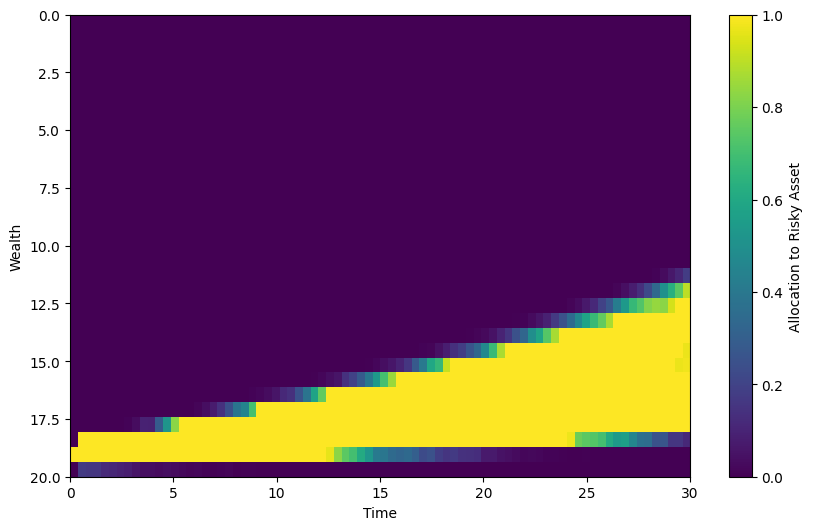

In [8]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.imshow(result.x.reshape((N, M)).T, aspect='auto', extent=[0, Wmax, T, 0], origin='lower', cmap='viridis')
plt.colorbar(label='Allocation to Risky Asset')
plt.ylabel('Wealth')
plt.xlabel('Time')


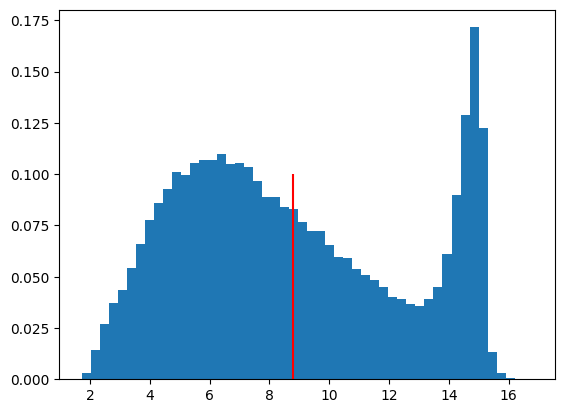

In [60]:
plt.hist(np.array(simulate_forward(bilinear_policy(result.x))[1])[-1, :], bins=50, density=True)
plt.vlines(np.mean(np.array(simulate_forward(bilinear_policy(result.x))[1])[-1, :]), 0, 0.1, color='red', label='Mean Wealth')

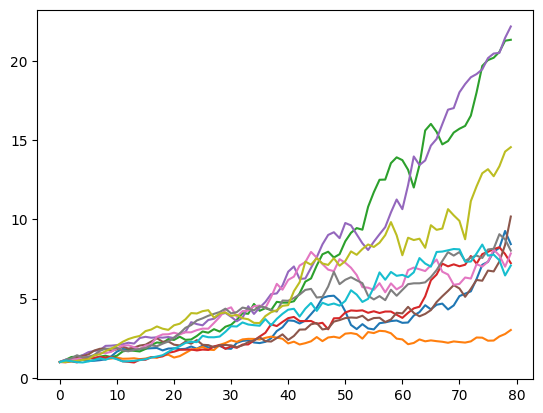

In [54]:
plt.plot(np.array(simulate_forward(bilinear_policy(result.x))[1])[:,:10])

In [ ]:
# === Adjoint MC Optimizer for Three Assets (Vectorized) === #
import numpy as np
from scipy.interpolate import RectBivariateSpline
from scipy.optimize import minimize

# === Model Parameters === #
r = 0.03
mu = np.array([0.0795, 0.07, 0.06])
sigma = np.array([0.15, 0.12, 0.09])
pi, w0 = 0.1, 1.0
pmin, pmax = 0.0, 1.0

T, dt, N = 20.0, 0.25, int(20.0 / 0.25)
K, Wmax, M, I = 100000, 30, 31, 3
lambda_risk = 2.0

wealth_grid = np.linspace(0, Wmax, M)
time_grid = np.linspace(0, T - dt, N)

# === Policy Function: p(t,W) returns vector of size I === #
def bilinear_policy(p_params):
    p_grid = p_params.reshape((N, M, I))
    interpolators = [RectBivariateSpline(time_grid, wealth_grid, p_grid[:, :, i], kx=1, ky=1) for i in range(I)]

    def p_func(t, W):
        W = np.clip(W, 0, Wmax)
        t = np.clip(t, 0, T - dt)
        p = np.array([interp.ev(t, W) for interp in interpolators])  # shape (I, K)
        return p.T  # shape (K, I)

    return p_func

# === Forward Simulation of Wealth Paths === #
def simulate_forward(p_func):
    W = np.full(K, w0)
    W_hist, S_hist, P_hist, dZ_hist = [], [], [], []

    for n in range(N):
        t = n * dt
        p = p_func(t, W)  # (K, I)
        drift = r + np.sum(p * (mu - r), axis=1)
        dZ = np.random.normal(0, np.sqrt(dt), (K, I))
        diffusion = np.sum(p * sigma * dZ, axis=1)
        S = 1 + drift * dt + diffusion

        W_hist.append(W.copy())
        S_hist.append(S.copy())
        P_hist.append(p.copy())
        dZ_hist.append(dZ.copy())

        W = W * S + pi * dt

    return W, W_hist, S_hist, P_hist, dZ_hist

# === Objective and Gradient using Adjoint Lagrangian === #
def objective_and_gradient(p_params):
    p_func = bilinear_policy(p_params)
    W_N, W_hist, S_hist, P_hist, dZ_hist = simulate_forward(p_func)

    mean_W, var_W = np.mean(W_N), np.var(W_N)
    J_lambda = mean_W - lambda_risk * var_W

    Y = (1 / K) - (2 * lambda_risk / K) * (W_N - mean_W)
    grad = np.zeros((N, M, I))

    for n in reversed(range(N)):
        Wn, Sn, pn, dZn = W_hist[n], S_hist[n], P_hist[n], dZ_hist[n]
        t = n * dt

        dS_dp = (mu - r) * dt + sigma * dZn  # shape (K, I)
        term = (Y * Wn)[:, None] * dS_dp  # (K, I)

        for m in range(M):
            Wm = wealth_grid[m]
            weight = np.maximum(1 - np.abs(Wn - Wm) / (Wmax / (M - 1)), 0)[:, None]
            grad[n, m, :] = np.sum(term * weight, axis=0) / K

        dS_dW = np.sum(pn * ((mu - r) * dt + sigma * dZn), axis=1) / Wn
        Y = dS_dW * Wn * Y + Sn * Y

    return -J_lambda, -grad.flatten()

# === Optimizer Interface === #
def objective(p_params):
    J, _ = objective_and_gradient(p_params)
    return J

def gradient(p_params):
    _, grad = objective_and_gradient(p_params)
    return grad

initial_p = 0.5 * np.ones((N, M, I)).flatten()
bounds = [(pmin, pmax)] * initial_p.size

result = minimize(objective, initial_p, method='L-BFGS-B', jac=gradient, bounds=bounds)

print("Optimization successful:", result.success)
print("Optimal objective value:", -result.fun)

